# 프로젝트 1. 영화 리뷰 감정 분석 (torchtext 없는 버전)

**torchtext 의존성 제거** — HuggingFace `datasets` + 표준 Python으로 대체

| 기존 (torchtext) | 대체 |
|---|---|
| `torchtext.datasets.IMDB` | `datasets.load_dataset('imdb')` |
| `get_tokenizer('basic_english')` | regex 기반 함수 |
| `build_vocab_from_iterator` | `collections.Counter` |

In [1]:
# datasets는 Colab에 기본 설치되어 있음. 없으면 아래 주석 해제
# !pip install datasets


In [2]:
import os
import re
import torch
import torch.nn as nn
import torch.nn.functional as F
from collections import Counter
from datasets import load_dataset          # HuggingFace 데이터셋 로더
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence  # 가변 길이 시퀀스 패딩 유틸


In [3]:
# 하이퍼파라미터
BATCH_SIZE = 64
lr = 0.001
EPOCHS = 10
MIN_FREQ = 5       # 어휘 사전에 포함할 최소 빈도
MAX_LEN  = 256     # 256: 기울기 경로 단축 → 초반부터 학습 시작
                   # 500: 더 많은 문맥 활용하지만 초반 plateau 길어짐

USE_CUDA = torch.cuda.is_available()
DEVICE = torch.device("cuda" if USE_CUDA else "cpu")
print("다음 기기로 학습합니다:", DEVICE)


다음 기기로 학습합니다: cuda


In [4]:
# 토크나이저 — torchtext 없이 regex로 구현
def tokenizer(text):
    text = text.lower()                          # 대소문자 통일
    text = re.sub(r'[^a-z0-9\s]', ' ', text)    # 영문자/숫자 외 문자를 공백으로 치환
    return text.split()


In [5]:
print("데이터 로딩중...")
# datasets 3.0+ 에서는 짧은 이름 'imdb' 해석 실패 (HfUriError).
# 정식 namespaced 이름 'stanfordnlp/imdb' 사용.
# label: 0=neg, 1=pos
try:
    raw_dataset = load_dataset('stanfordnlp/imdb')
except Exception as e:
    # HF Hub 접근 실패 시 Stanford 원본 URL에서 직접 다운로드하는 폴백 처리
    print(f"HF Hub 로드 실패 ({type(e).__name__}): {e}")
    print("Stanford 원본에서 직접 다운로드 시도...")
    import urllib.request, tarfile, glob
    URL = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"
    TAR = "./aclImdb_v1.tar.gz"
    DIR = "./aclImdb"
    if not os.path.isdir(DIR):
        urllib.request.urlretrieve(URL, TAR)
        with tarfile.open(TAR) as tf:
            tf.extractall(".")

    def _load_split(split):
        # 각 분할(train/test)의 neg/pos 폴더에서 텍스트와 레이블을 읽어 딕셔너리로 반환
        texts, labels = [], []
        for lbl_name, lbl_id in [('neg', 0), ('pos', 1)]:
            for path in glob.glob(f"{DIR}/{split}/{lbl_name}/*.txt"):
                with open(path, encoding='utf-8') as f:
                    texts.append(f.read())
                labels.append(lbl_id)
        return {'text': texts, 'label': labels}

    from datasets import Dataset as HFDataset, DatasetDict
    raw_dataset = DatasetDict({
        'train': HFDataset.from_dict(_load_split('train')),
        'test':  HFDataset.from_dict(_load_split('test')),
    })

print(f"train: {len(raw_dataset['train'])}개, test: {len(raw_dataset['test'])}개")


데이터 로딩중...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:122: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

train: 25000개, test: 25000개


In [6]:
# 학습 데이터로 어휘 사전 구축 (Counter 사용)
print("어휘 사전 구축중...")
counter = Counter()
for item in raw_dataset['train']:
    counter.update(tokenizer(item['text']))

# 특수 토큰: <unk>=0 (미등록어), <pad>=1 (패딩)
SPECIALS = ['<unk>', '<pad>']
# MIN_FREQ 이상 등장한 단어만 어휘 사전에 포함 (저빈도 노이즈 제거)
vocab_words = SPECIALS + [w for w, cnt in counter.most_common() if cnt >= MIN_FREQ]
word2idx = {word: idx for idx, word in enumerate(vocab_words)}

UNK_IDX = word2idx['<unk>']
PAD_IDX = word2idx['<pad>']
vocab_size = len(word2idx)
print(f"어휘 사전 크기: {vocab_size}")


어휘 사전 구축중...
어휘 사전 크기: 29125


In [7]:
def text_to_indices(text):
    tokens = tokenizer(text)[:MAX_LEN]   # 긴 리뷰를 MAX_LEN으로 잘라냄
    # 사전에 없는 단어는 UNK_IDX로 대체
    return [word2idx.get(tok, UNK_IDX) for tok in tokens]


In [8]:
# PyTorch Dataset 클래스
class IMDBDataset(Dataset):
    def __init__(self, hf_dataset):
        self.data = hf_dataset

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        # 텍스트를 인덱스 시퀀스로 변환해 텐서로 반환
        text_ids = torch.tensor(text_to_indices(item['text']), dtype=torch.long)
        label = torch.tensor(item['label'], dtype=torch.long)
        return text_ids, label


# 배치 내 길이가 다른 시퀀스를 PAD로 정렬
def collate_fn(batch):
    texts, labels = zip(*batch)
    # 배치 내 가장 긴 시퀀스 기준으로 나머지를 PAD_IDX로 채움
    texts_padded = pad_sequence(texts, batch_first=True, padding_value=PAD_IDX)
    return texts_padded, torch.stack(labels)


In [9]:
# train 25000개를 80/20으로 나눠 train/val 생성
# 반드시 shuffle 먼저!
#   IMDB 원본은 레이블 순서(긍정 12500개 → 부정 12500개)로 정렬되어 있음.
#   shuffle 없이 뒤쪽 20%를 val로 쓰면 val이 부정 레이블만 5000개가 되어
#   모델이 긍정으로 편향 학습 → val 정확도 ~0%, 테스트 정확도 ~50%가 됨.
train_raw = raw_dataset['train'].shuffle(seed=42)
test_raw  = raw_dataset['test']

split_idx  = int(len(train_raw) * 0.8)   # 20000
train_data = train_raw.select(range(split_idx))
val_data   = train_raw.select(range(split_idx, len(train_raw)))

trainset = IMDBDataset(train_data)
valset   = IMDBDataset(val_data)
testset  = IMDBDataset(test_raw)

# shuffle=True: 매 에포크마다 데이터 순서를 섞어 학습 편향 방지
train_iter = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn)
val_iter   = DataLoader(valset,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_iter  = DataLoader(testset,  batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

n_classes = 2
print("[학습셋]: %d [검증셋]: %d [테스트셋]: %d [단어수]: %d [클래스] %d"
      % (len(trainset), len(valset), len(testset), vocab_size, n_classes))


[학습셋]: 20000 [검증셋]: 5000 [테스트셋]: 25000 [단어수]: 29125 [클래스] 2


In [10]:
# 원본과 동일한 BasicGRU 모델
# v1(torchtext)과 달리 pack_padded_sequence를 사용하지 않고
# Embedding의 padding_idx 인수로 PAD 위치의 기울기를 자동으로 0으로 처리
class BasicGRU(nn.Module):
    def __init__(self, n_layers, hidden_dim, n_vocab, embed_dim, n_classes, dropout_p=0.2):
        super(BasicGRU, self).__init__()
        print("Building Basic GRU model...")
        self.n_layers = n_layers
        # padding_idx: PAD 위치의 임베딩 벡터를 항상 0으로 고정해 PAD가 학습에 영향 안 미치게 함
        self.embed = nn.Embedding(n_vocab, embed_dim, padding_idx=PAD_IDX)
        self.hidden_dim = hidden_dim
        self.dropout = nn.Dropout(dropout_p)
        self.gru = nn.GRU(embed_dim, self.hidden_dim,
                          num_layers=self.n_layers,
                          batch_first=True)
        # GRU 마지막 은닉 상태 -> 클래스 로짓으로 변환하는 분류 헤드
        self.out = nn.Linear(self.hidden_dim, n_classes)

    def forward(self, x):
        x = self.embed(x)          # (B, T, embed_dim)
        x = self.dropout(x)
        _, h_n = self.gru(x)       # h_n: (n_layers, B, hidden_dim)
        h_n = h_n[-1]              # 마지막 레이어 hidden state를 리뷰 전체의 압축 표현으로 사용
        logit = self.out(h_n)
        return logit


In [11]:
def train(model, optimizer, train_iter):
    model.train()
    total_loss = 0
    for x, y in train_iter:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        logit = model(x)
        loss = F.cross_entropy(logit, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(train_iter)   # 배치 평균 손실 반환


def evaluate(model, data_iter):
    model.eval()
    corrects, total_loss = 0, 0
    with torch.no_grad():  # 평가 시에는 그래디언트 계산 불필요
        for x, y in data_iter:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logit = model(x)
            # reduction='sum': 샘플 수로 나누어 전체 평균을 직접 계산하기 위해 합산
            loss = F.cross_entropy(logit, y, reduction='sum')
            total_loss += loss.item()
            corrects += (logit.max(1)[1] == y).sum().item()
    size = len(data_iter.dataset)
    avg_loss = total_loss / size
    avg_accuracy = 100.0 * corrects / size
    return avg_loss, avg_accuracy


In [12]:
model = BasicGRU(1, 256, vocab_size, 128, n_classes, 0.5).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
print(model)


Building Basic GRU model...
BasicGRU(
  (embed): Embedding(29125, 128, padding_idx=1)
  (dropout): Dropout(p=0.5, inplace=False)
  (gru): GRU(128, 256, batch_first=True)
  (out): Linear(in_features=256, out_features=2, bias=True)
)


In [13]:
train_losses, val_losses, val_accuracies = [], [], []

best_val_loss = None
for e in range(1, EPOCHS + 1):
    train_loss = train(model, optimizer, train_iter)
    val_loss, val_accuracy = evaluate(model, val_iter)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    print("[이폭: %d] 학습 오차:%5.2f | 검증 오차:%5.2f | 검증 정확도:%5.2f"
          % (e, train_loss, val_loss, val_accuracy))

    # 검증 손실이 개선될 때만 모델 가중치 저장 (조기 종료 대용)
    if not best_val_loss or val_loss < best_val_loss:
        if not os.path.isdir("snapshot"):
            os.makedirs("snapshot")
        torch.save(model.state_dict(), './snapshot/txtclassification.pt')
        best_val_loss = val_loss


[이폭: 1] 학습 오차: 0.70 | 검증 오차: 0.69 | 검증 정확도:51.04
[이폭: 2] 학습 오차: 0.69 | 검증 오차: 0.69 | 검증 정확도:51.60
[이폭: 3] 학습 오차: 0.69 | 검증 오차: 0.67 | 검증 정확도:60.56
[이폭: 4] 학습 오차: 0.68 | 검증 오차: 0.69 | 검증 정확도:50.26
[이폭: 5] 학습 오차: 0.67 | 검증 오차: 0.70 | 검증 정확도:52.00
[이폭: 6] 학습 오차: 0.65 | 검증 오차: 0.62 | 검증 정확도:69.36
[이폭: 7] 학습 오차: 0.57 | 검증 오차: 0.48 | 검증 정확도:78.52
[이폭: 8] 학습 오차: 0.38 | 검증 오차: 0.36 | 검증 정확도:84.60
[이폭: 9] 학습 오차: 0.30 | 검증 오차: 0.35 | 검증 정확도:85.88
[이폭: 10] 학습 오차: 0.26 | 검증 오차: 0.35 | 검증 정확도:85.92


In [14]:
# 가장 좋은 가중치를 불러와 최종 테스트 수행
model.load_state_dict(torch.load('./snapshot/txtclassification.pt'))
test_loss, test_acc = evaluate(model, test_iter)
print('테스트 오차: %5.2f | 테스트 정확도: %5.2f' % (test_loss, test_acc))


테스트 오차:  0.35 | 테스트 정확도: 85.91


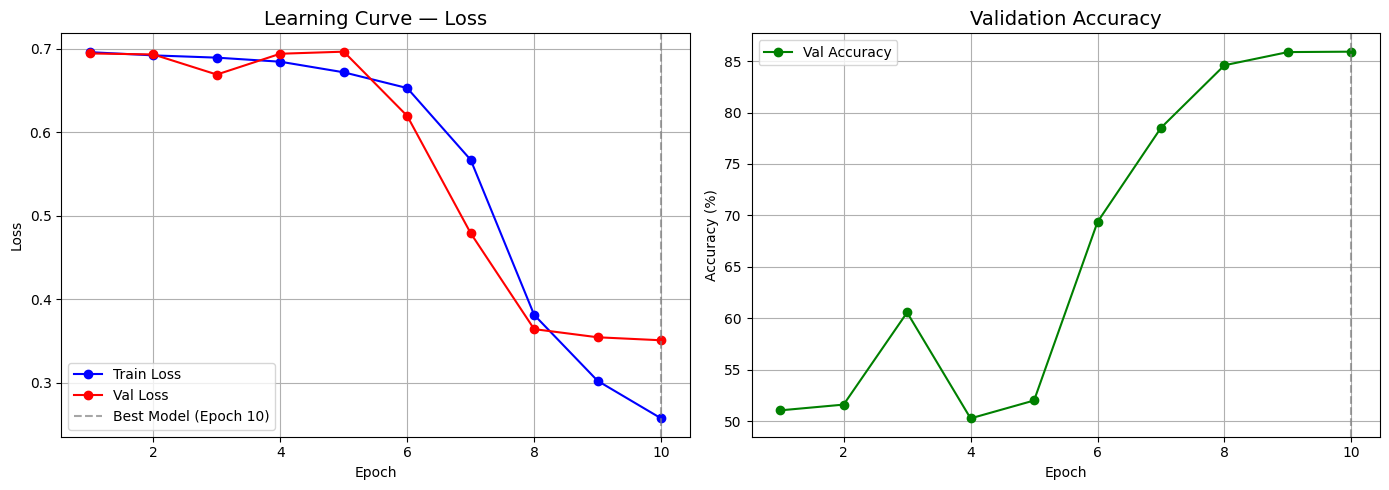


Best model: Epoch 10 | Val Loss 0.3507


In [15]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
ax1.plot(epochs, train_losses, 'b-o', label='Train Loss')
ax1.plot(epochs, val_losses,   'r-o', label='Val Loss')
ax1.set_title('Learning Curve — Loss', fontsize=14)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# 검증 손실이 가장 낮은 에포크에 수직선 표시 (최적 모델 저장 시점)
best_epoch = val_losses.index(min(val_losses)) + 1
ax1.axvline(x=best_epoch, color='gray', linestyle='--', alpha=0.7,
            label=f'Best Model (Epoch {best_epoch})')
ax1.legend()

# Accuracy curve
ax2.plot(epochs, val_accuracies, 'g-o', label='Val Accuracy')
ax2.set_title('Validation Accuracy', fontsize=14)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True)
ax2.axvline(x=best_epoch, color='gray', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('learning_curve.png', dpi=120)
plt.show()
print(f"\nBest model: Epoch {best_epoch} | Val Loss {min(val_losses):.4f}")
